## Using ModelWrapper To Import Salt Checkpoints
The ModelWrapper is a useful object from salt-ml for using pytorch lightning methods on standard torch modules. THE CHECKPOINT IS SAVED IN SALT-ML 0.9.0, requiring Python versions 3.10 or 3.11 to use. This requires the creation of virtual environment if this is not the version you are currently using. This has the added benefit of not messing up other code when having to install earlier versions of packages. Information on how to achieve this and run it in a Jupyter notebook is given below:

### Creating A Virtual Environment
A virtual environment can be created using uv - details of how to install this can be found here: https://docs.astral.sh/uv/getting-started/installation/#__tabbed_1_1

To create a kernel in jupyterlab using a different version of python you can follow the instructions here: https://discourse.jupyter.org/t/how-to-manage-multiple-python-versions-and-environments/38072/3

From the command line you can now install the necessary packages using uv pip install package_name==version - this ensures that the version specified is the correct one required, eg for salt-ml you need version 0.9.0. The .ckpt file was uploaded around June 2025 so try to install versions of packages from around that time if there are any dependency issues. There will probably be an issue with something called pkg_resources - this can be solved by installing a version less than 81.0 of a package called setuptools.

### Loading The Checkpoint
All packages required are given below. We can then load in both the checkpoint and the h5 data file we want to run inference on. 

In [54]:
import h5py, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from salt.modelwrapper import ModelWrapper

In [49]:
CKPT   = "epoch=012-val_loss=0.59505.ckpt" # model checkpoint

NORM   = "norm_dict.yaml" # where the normalisation values are for each input parameter in the model - this is the normalisations determined from the data 
                        # the model was TRAINED on -  not normalisation values for the dataset you want to run inference on

FILE   = "mc-flavtag-ttbar-small.h5" # dataset we want to run inference on

N      = 30000 # size of batch of jets we will feed into our model to generate predictions

STORED = "GN2v01"        # stored tagger in this file (production model; not the open-data ckpt) 
                        # inside the open data file there are a series of predictions from both GN2v01 and DL1d 
                        # we want the GN2v01 data for comparison

TRK = ["d0", "z0SinTheta", "dphi", "deta", "qOverP", "lifetimeSignedD0Significance",

       "lifetimeSignedZ0SinThetaSignificance", "phiUncertainty", "thetaUncertainty", "qOverPUncertainty",

       "numberOfPixelHits", "numberOfSCTHits", "numberOfInnermostPixelLayerHits",

       "numberOfNextToInnermostPixelLayerHits", "numberOfInnermostPixelLayerSharedHits",

       "numberOfInnermostPixelLayerSplitHits", "numberOfPixelSharedHits", "numberOfPixelSplitHits",

       "numberOfSCTSharedHits"] # listing the track variables we want to feed into our model from FILE


### Loading the Model
We can now load our model and prepare our inference data for feeding into the model.

In [50]:
norm_config = dict(torch.load(CKPT, map_location="cpu", weights_only=False)["hyper_parameters"]["norm_config"]) # extracting norm_config from the checkpoint

norm_config["norm_dict"] = NORM # attaching the norm dictionary into the norm config

model = ModelWrapper.load_from_checkpoint(CKPT, map_location="cpu", norm_config=norm_config).eval() # loading the model using the lightning method
                    # to load directly from the checkpoint, also setting the model to eval mode

In [51]:
with h5py.File(FILE, "r") as f:

    jets = pd.DataFrame(f["jets"][:N]) # extracting jets and tracks values from FILE

    tracks = f["tracks"][:N]

x_jets = torch.tensor(jets[["pt_btagJes", "eta_btagJes"]].to_numpy(np.float32))   # RAW inputs (pt in MeV) 

x_trk = torch.tensor(np.stack([tracks[v] for v in TRK], -1).astype(np.float32)) # converting track and jet data to torch tensors

pad = torch.tensor(~tracks["valid"].astype(bool)) # identifying where a mask has been used
 
x_trk[pad] = 0.0 # setting the mask to have value of zero

### Running Inference

In [52]:
with torch.no_grad():  # running inference using the model

    out = model({"jets": x_jets, "tracks": x_trk}, {"tracks": pad}) # getting scores

probs = torch.softmax(out[0]["jets"]["jets_classification"], -1).numpy()           # (N,4) = pb,pc,pu,ptau - order of the output probabilities
                                                                                # using softmax to convert to probabilities

We can perform a quick evaluation of the predictions by histogramming them.

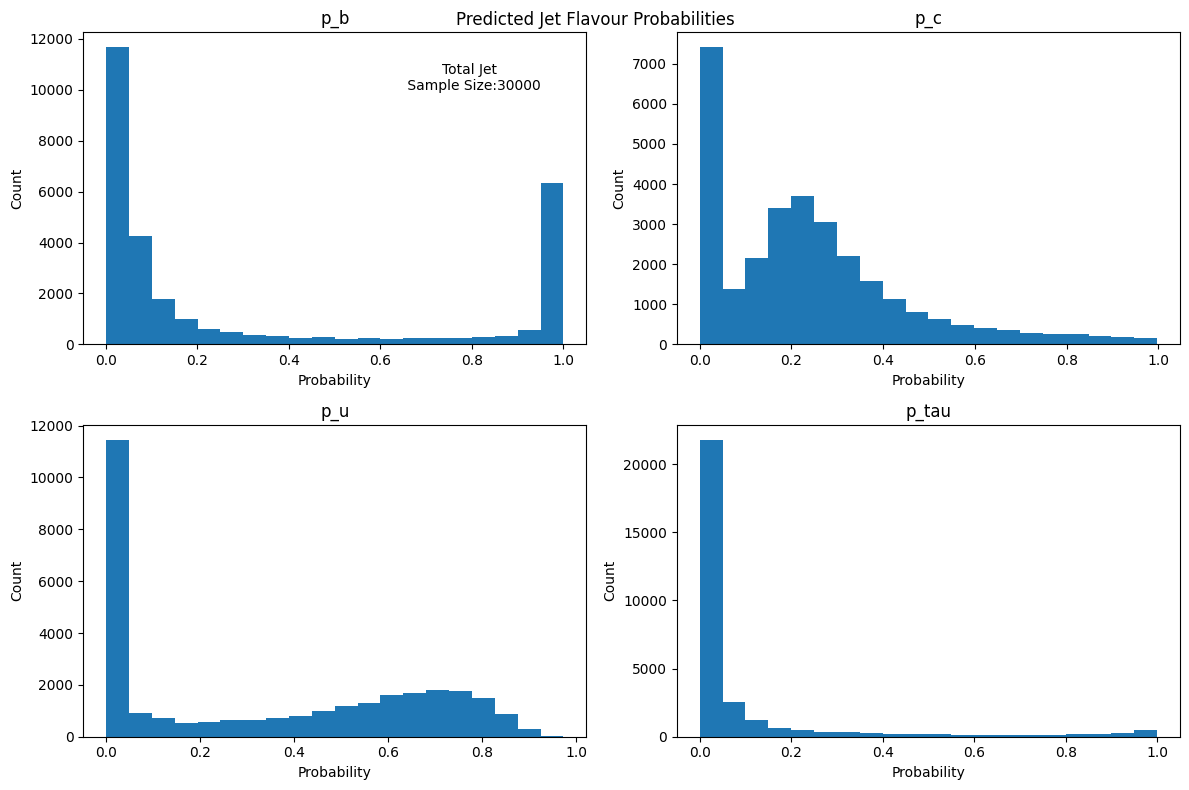

In [57]:
flav_classes = np.array(["b","c","u","tau"])

fig = plt.figure(figsize=(12,8))
for n in range(4):
    ax = fig.add_subplot(2,2,n+1)
    ax.hist(probs[:,n],bins=20)
    ax.set_xlabel("Probability")
    ax.set_ylabel("Count")
    ax.set_title(f'p_{flav_classes[n]}')
    if n == 0:
        ax.text(x=0.8,y=10000,s=f'Total Jet \n Sample Size:{N}',ha="center")
fig.tight_layout()
fig.suptitle(f'Predicted Jet Flavour Probabilities')
plt.savefig("ProbabilityHistogram.png")
plt.show()

### Evaluating Predictions
Having obtained model predictions for a batch of inference data, we want to compare these predictions to those given by GN2v01, as listed in the open-dataet file and compared to their truth values.

In [53]:
stored = jets[[f"{STORED}_pb", f"{STORED}_pc", f"{STORED}_pu", f"{STORED}_ptau"]].to_numpy() # are the GN2 predictions from FILE

diff = pd.DataFrame(probs - stored, columns=["d_pb", "d_pc", "d_pu", "d_ptau"]) # calculate the difference between GN2 probabilites and our model's for the 
                                                                                # given jet

diff["truth"] = jets["HadronConeExclTruthLabelID"].map({5: "b", 4: "c", 0: "light", 15: "tau"}).values # the open dataset also contains the truth value for each
                # jet, obtained in a different manner

print(f"mean (open-data - {STORED}) per truth flavour:")

print(diff.groupby("truth").mean()) # grouping the mean difference between our model's prediction and the GN2 prediction by the truth value for the jets
                                    # the lower the number the better

mean (open-data - GN2v01) per truth flavour:
           d_pb      d_pc      d_pu    d_ptau
truth                                        
b      0.092415 -0.013380 -0.023056 -0.002473
c      0.058549  0.018336 -0.082774  0.006092
light  0.034539  0.082117 -0.137579  0.020987
tau    0.019859  0.015325 -0.035911  0.003465


#### Future Improvements
- Use salt data sampler to take a more representative batch of datapoints
- Use YODA package to visualise probability distributions with respect to p$_T$ and $\eta$.